# IMPORTACIONES Y CONFIGURACIÓN CSV 

In [28]:
#importamos librerías 

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import datetime

In [2]:
#importamos librerías para el preprocesamiento de datos

import warnings 
warnings.filterwarnings('ignore', category=FutureWarning)

In [3]:
#configuramos pandas para mostrar todas las columnas del dataframe

pd.set_option('display.max_columns', None)

# FASE 1 - EXPLORACIÓN Y LIMPIEZA 

# 1. EXPLORACIÓN INICIAL 

# LECTURA DATASET 

In [4]:
#cargamos el primer dataset
df_1 = pd.read_csv("files/Customer Flight Activity.csv")
#mostramos las cinco primeras filas del dataframe 
df_1.head(5)

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0


In [5]:
#cargamos el segundo dataset
df_2 = pd.read_csv("files/Customer Loyalty History.csv")
#mostramos las cinco primeras filas del dataframe
df_2.head(5)

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


# MÉTODOS PARA FAMILIARIZARNOS CON LOS CSVs 

In [6]:
#El método sample nos devuelve una muestra aleatoria de filas del dataframe
df_1.sample(5)

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
396720,526765,2018,12,10,0,10,3390,339.0,0,0
212527,564141,2017,7,10,0,10,4090,409.0,0,0
391484,248752,2018,12,11,8,19,3933,393.0,0,0
96480,736459,2017,6,0,0,0,0,0.0,0,0
53680,260464,2017,4,4,0,4,1788,178.0,0,0


In [7]:
#El método info nos devuelve un resumen de la información del dataframe, incluyendo el número de filas, el número de columnas, 
#el tipo de datos de cada columna y el número de valores no nulos en cada columna.
#Vemos que hay 10 columnas, 9 de tipo int64 y 1 de tipo float64. 
df_1.info()


<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


In [8]:
#Utilizamos el método describe para obtener un resumen estadístico de las columnas numéricas del df_1 (todas son numéricas)
df_1.describe()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
count,405624.000000,405624.000000,405624.000000,405624.000000,405624.000000,405624.000000,405624.000000,405624.000000,405624.000000,405624.000000
mean,550037.873084,2017.500000,6.500000,4.115052,1.031805,5.146858,1208.880059,123.692721,30.696872,2.484503
std,258935.286969,0.500001,3.452057,5.225518,2.076869,6.521227,1433.155320,146.599831,125.486049,10.150038
min,100018.000000,2017.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326961.000000,2017.000000,3.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,550834.000000,2017.500000,6.500000,1.000000,0.000000,1.000000,488.000000,50.000000,0.000000,0.000000
75%,772194.000000,2018.000000,9.250000,8.000000,1.000000,10.000000,2336.000000,239.000000,0.000000,0.000000
max,999986.000000,2018.000000,12.000000,21.000000,11.000000,32.000000,6293.000000,676.500000,876.000000,71.000000


In [9]:
#El método shape nos devuelve el número de filas y columnas del df_1
print(f"El número de filas que tenemos es {df_1.shape[0]}, y el número de columnas es {df_1.shape[1]}")

El número de filas que tenemos es 405624, y el número de columnas es 10


In [10]:
#El método duplicated nos devuelve un booleano indicando si cada fila es un duplicado de una fila anterior. El método sum nos devuelve el número total de filas duplicadas.
df_1.duplicated().sum()

np.int64(1864)

In [11]:
#El método duplicated con el parámetro subset nos permite especificar una columna o un conjunto de columnas para identificar filas duplicadas. 
#En este caso, estamos buscando filas duplicadas basándonos en la columna "Loyalty Number". 
df_1.duplicated(subset="Loyalty Number", keep=False).sum()

np.int64(405624)

In [12]:
#Estos duplicados son un error de inserción? se pueden eliminar?
#Devuelve una lista de todas las filas que están repetidas, mostrando el contenido de la fila y una columna al lado que indica el número total de repeticiones

df_1[df_1.duplicated(keep=False)].value_counts()

Loyalty Number  Year  Month  Flights Booked  Flights with Companions  Total Flights  Distance  Points Accumulated  Points Redeemed  Dollar Cost Points Redeemed
678205          2017  1      0               0                        0              0         0.0                 0                0                              3
                      2      0               0                        0              0         0.0                 0                0                              3
                      3      0               0                        0              0         0.0                 0                0                              3
                      4      0               0                        0              0         0.0                 0                0                              3
                      5      0               0                        0              0         0.0                 0                0                              3
               

In [13]:
#El método columns nos devuelve una lista con los nombres de las columnas del df_1
df_1.columns

Index(['Loyalty Number', 'Year', 'Month', 'Flights Booked',
       'Flights with Companions', 'Total Flights', 'Distance',
       'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed'],
      dtype='str')

En este dataframe no es necesasrio aplicar filtros para identificar valores únicos porque todos mantienen integridad estructural. La única columna que podía tener alguna problemática es 'Month' al ser 12 valores únicos (uno por mes). Ha sido inspeccionada y no hay ningún error. 

In [14]:
#El método isna nos devuelve un booleano indicando si cada valor es nulo o no. El método sum nos devuelve el número total de valores nulos en cada columna.
df_1.isna().sum()
#Vemos que en el df_1 no hay valores nulos, no hace falta decidir qué hacer con ellos ni obtener el porcentaje. 

Loyalty Number                 0
Year                           0
Month                          0
Flights Booked                 0
Flights with Companions        0
Total Flights                  0
Distance                       0
Points Accumulated             0
Points Redeemed                0
Dollar Cost Points Redeemed    0
dtype: int64

In [15]:
#El método sample nos devuelve una muestra aleatoria de filas del dataframe
df_2.sample(5)

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
1831,428383,Canada,Ontario,Toronto,P1J 8T7,Female,College,NaN,Single,Aurora,6826.80,Standard,2013,3,2017.0,3.0
11914,351138,Canada,Saskatchewan,Regina,S6J 3G0,Female,Bachelor,76565.0,Single,Star,2836.68,Standard,2014,7,NaN,NaN
12315,505790,Canada,Alberta,Edmonton,T3G 6Y6,Female,Bachelor,73008.0,Married,Star,3570.76,Standard,2013,1,NaN,NaN
91,645265,Canada,Quebec,Quebec City,G1B 3L5,Male,Bachelor,73313.0,Married,Star,4013.95,Standard,2013,3,NaN,NaN
10273,195977,Canada,Ontario,Toronto,P1L 8X8,Female,College,NaN,Married,Star,2388.95,Standard,2017,3,NaN,NaN


In [16]:
#El método info nos devuelve un resumen de la información del dataframe, incluyendo el número de filas, el número de columnas, 
#el tipo de datos de cada columna y el número de valores no nulos en cada columna.
#Vemos que hay 16 columnas, 9 de ellas son de tipo string, 3 de tipo int64 y 4 de tipo float64. 
df_2.info()
#Vemos que este método nos indica que no hay nulos, pero la realidad es que sí hay solo que están representados por una máscara. 
    

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: float64(4), 

In [17]:
#En este caso el método describe no es suficiente porque las columnas son numéricas y categóricas 
df_2.describe().T 

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,16737.0,549735.880445,258912.132453,100018.00,326603.00,550434.00,772019.00,999986.00
Salary,12499.0,79245.609409,35008.297285,-58486.00,59246.50,73455.00,88517.50,407228.00
CLV,16737.0,7988.896536,6860.982280,1898.01,3980.84,5780.18,8940.58,83325.38
Enrollment Year,16737.0,2015.253211,1.979111,2012.00,2014.00,2015.00,2017.00,2018.00
Enrollment Month,16737.0,6.669116,3.398958,1.00,4.00,7.00,10.00,12.00
Cancellation Year,2067.0,2016.503145,1.380743,2013.00,2016.00,2017.00,2018.00,2018.00
Cancellation Month,2067.0,6.962748,3.455297,1.00,4.00,7.00,10.00,12.00


In [18]:
#Añadimos el parámetro include='str' para obtener un resumen estadístico de las columnas de tipo string del df_2
df_2.describe(include='str').T

,count,unique,top,freq
Country,16737,1,Canada,16737
Province,16737,11,Ontario,5404
City,16737,29,Toronto,3351
Postal Code,16737,55,V6E 3D9,911
Gender,16737,2,Female,8410
Education,16737,5,Bachelor,10475
Marital Status,16737,3,Married,9735
Loyalty Card,16737,3,Star,7637
Enrollment Type,16737,2,Standard,15766


In [26]:
#Identificamos outliers en estas dos columnas del df_2
df_2[['Salary', 'CLV']].describe() 


,Salary,CLV
count,12499.000000,16737.000000
mean,79245.609409,7988.896536
std,35008.297285,6860.982280
min,-58486.000000,1898.010000
25%,59246.500000,3980.840000
50%,73455.000000,5780.180000
75%,88517.500000,8940.580000
max,407228.000000,83325.380000


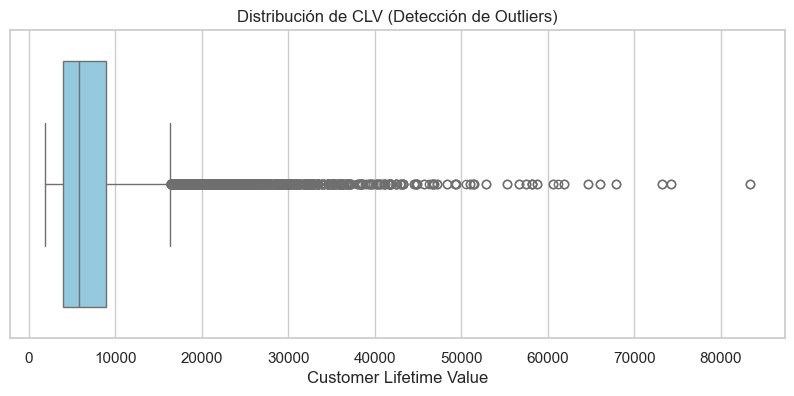

In [33]:
# Configuramos el estilo
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_2['CLV'], color="skyblue")

plt.title('Distribución de CLV (Detección de Outliers)')
plt.xlabel('Customer Lifetime Value')
plt.show()

#Los outliers son los clientes de alto valor para la empresa y la media está sesgada por ellos. 

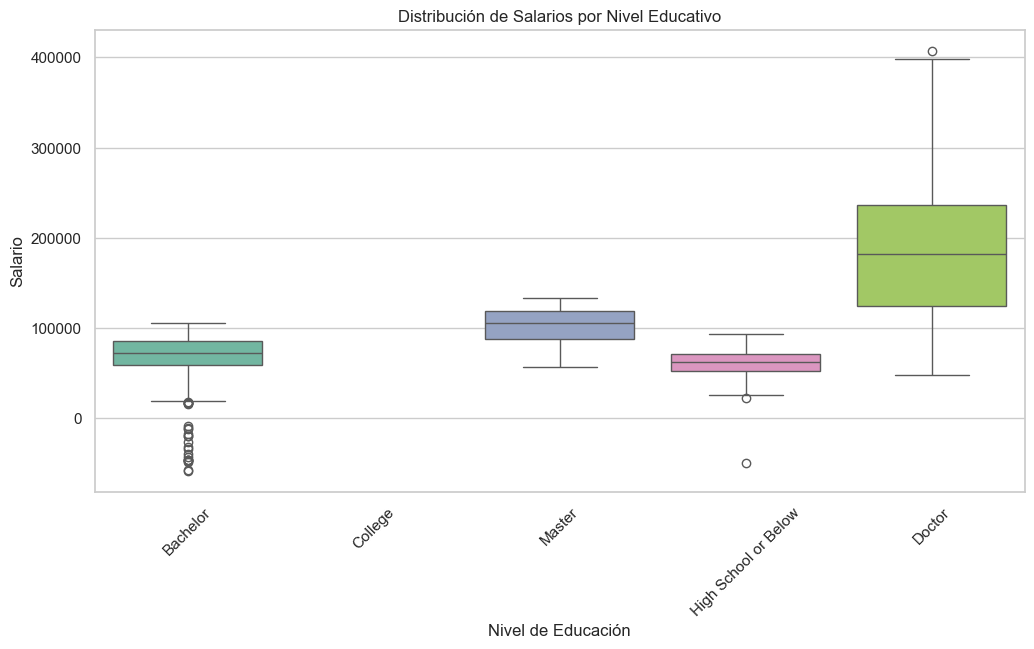

In [36]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_2, x='Education', y='Salary', palette="Set2")

plt.title('Distribución de Salarios por Nivel Educativo')
plt.xlabel('Nivel de Educación')
plt.ylabel('Salario')
plt.xticks(rotation=45) # Para que se lean bien los nombres
plt.show()

#Hay outliers en el salario de bachelor y highschool or below. Y no hay ningún dato de salario en college. 

In [31]:
#hay años de registro futuros? 
# Si hay algo mayor a 2018, es un error de entrada
futuros_dataset = df_2[df_2['Enrollment Year'] > 2018]

print(f"Registros con años futuros: {len(futuros_dataset)}")
if len(futuros_dataset) > 0:
    print(futuros_dataset[['Loyalty Number', 'Enrollment Year']])

Registros con años futuros: 0


In [19]:
#El método shape nos devuelve el número de filas y columnas del df_2
print(f"El número de filas que tenemos es {df_2.shape[0]}, y el número de columnas es {df_2.shape[1]}")

El número de filas que tenemos es 16737, y el número de columnas es 16


In [20]:
#No hay filas duplicadas en el df_2
df_2.duplicated().sum()

np.int64(0)

In [21]:
df_2.columns

Index(['Loyalty Number', 'Country', 'Province', 'City', 'Postal Code',
       'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card',
       'CLV', 'Enrollment Type', 'Enrollment Year', 'Enrollment Month',
       'Cancellation Year', 'Cancellation Month'],
      dtype='str')

In [22]:
#El método unique nos devuelve una lista de los valores únicos de la columna "Country" del df_2
df_2["Country"].unique()
#Observamos que solo hay un valor - Canada - posible drop?

<StringArray>
['Canada']
Length: 1, dtype: str

In [27]:
#Compruebo si hay algún otro valor que no sea necesario a la hora del análisis. Pero todos los demás son necesarios. 
df_2.select_dtypes(include='object').nunique()

C:\Users\danmo\AppData\Local\Temp\ipykernel_15148\2486547985.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_2.select_dtypes(include='object').nunique()


Country             1
Province           11
City               29
Postal Code        55
Gender              2
Education           5
Marital Status      3
Loyalty Card        3
Enrollment Type     2
dtype: int64

Después de aplicar el método .unique al resto de columnas, la columna country es la única que aporta información relevante.

In [23]:
#El método isna nos devuelve un booleano indicando si cada valor es nulo o no. El método sum nos devuelve el número total de valores nulos en cada columna.
df_2.isna().sum()

Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                 4238
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

In [24]:
#Obtenemos el porcentaje de valores nulos en cada columna del df_2
df_2.isna().sum()/df_2.shape[0]*100

Loyalty Number         0.000000
Country                0.000000
Province               0.000000
City                   0.000000
Postal Code            0.000000
Gender                 0.000000
Education              0.000000
Salary                25.321145
Marital Status         0.000000
Loyalty Card           0.000000
CLV                    0.000000
Enrollment Type        0.000000
Enrollment Year        0.000000
Enrollment Month       0.000000
Cancellation Year     87.650117
Cancellation Month    87.650117
dtype: float64

In [25]:
# Obtenemos el número de valores nulos en la columna "Salary" agrupados por la columna "Education"
# Vemos que todos los nulos vienen de "College" dentro de "Education"
df_2.groupby('Education')['Salary'].apply(lambda x: x.isnull().sum())

Education
Bachelor                   0
College                 4238
Doctor                     0
High School or Below       0
Master                     0
Name: Salary, dtype: int64

# UNION DFs

In [32]:
#Antes de unirlos, comprobamos que todos los clientes de vuelos existen en el de historia 
ids_vuelos = set(df_1['Loyalty Number'])
ids_historia = set(df_2['Loyalty Number'])

print(f"IDs en vuelos pero no en historia: {len(ids_vuelos - ids_historia)}")

IDs en vuelos pero no en historia: 0


In [38]:
#Borramos la columna de "Country" del df_2 porque solo tiene un valor y no aporta información relevante para el análisis.
df_2.drop(columns=['Country'], inplace=True)

In [39]:
#Imprimo df_2 para comprobar que se ha borrado la columna de "Country"
df_2.head()

,Loyalty Number,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


# ¿Por qué elijo merge?
Porque usca coincidencias basadas en el contenido de una columna, en este caso Loyalty Number. 
Así nos aseguramos de que la información en el df_unido es correcta.
# ¿Por qué elijo left? 
Usamos left porque nuestra unidad de análisis es el vuelo realizado. Queremos conservar cada vuelo registrado, incluso si por algún error ese cliente no apareciera en la tabla de perfiles (aunque lo ideal es que aparezca). Si usaras inner, y un cliente no estuviera en la tabla de historia, perderías sus datos de vuelos en el resultado final.

In [41]:
# Realizamos la unión
df_unido = pd.merge(df_1, df_2, on='Loyalty Number', how='left')

# Comprobación post-merge
print(f"Filas originales vuelos: {df_1.shape[0]}")
print(f"Filas tras el merge: {df_unido.shape[0]}")
#Esto comprueba que no había duplicados en df_2 

Filas originales vuelos: 405624
Filas tras el merge: 405624


In [45]:
df_unido.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN
1,100102,2017,1,10,4,14,2030,203.0,0,0,Ontario,Toronto,M1R 4K3,Male,College,NaN,Single,Nova,2887.74,Standard,2013,3,NaN,NaN
2,100140,2017,1,6,0,6,1200,120.0,0,0,British Columbia,Dawson Creek,U5I 4F1,Female,College,NaN,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN
3,100214,2017,1,0,0,0,0,0.0,0,0,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,NaN,NaN
4,100272,2017,1,0,0,0,0,0.0,0,0,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN


In [48]:
print("Forma del dataset unido:", df_final.shape)

Forma del dataset unido: (405624, 24)


In [42]:
#Exploro el dataframe unido para comprobar que se ha hecho correctamente la unión y que no hay valores nulos en las columnas de df_1.
df_unido.info()

<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
 10  Province                     405624 non-null  str    
 11  City                         405624 non-null  str    
 12  Postal Code                  405624 non-null  str    
 13  Gender    

In [43]:
#Obtenemos un resumen estadístico de las columnas numéricas del df_unido para comprobar que se han unido correctamente y que no hay valores nulos en las columnas de df_1.
df_unido.describe().T

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,405624.0,550037.873084,258935.286969,100018.00,326961.00,550834.00,772194.00,999986.00
Year,405624.0,2017.500000,0.500001,2017.00,2017.00,2017.50,2018.00,2018.00
Month,405624.0,6.500000,3.452057,1.00,3.75,6.50,9.25,12.00
Flights Booked,405624.0,4.115052,5.225518,0.00,0.00,1.00,8.00,21.00
Flights with Companions,405624.0,1.031805,2.076869,0.00,0.00,0.00,1.00,11.00
Total Flights,405624.0,5.146858,6.521227,0.00,0.00,1.00,10.00,32.00
Distance,405624.0,1208.880059,1433.155320,0.00,0.00,488.00,2336.00,6293.00
Points Accumulated,405624.0,123.692721,146.599831,0.00,0.00,50.00,239.00,676.50
Points Redeemed,405624.0,30.696872,125.486049,0.00,0.00,0.00,0.00,876.00
Dollar Cost Points Redeemed,405624.0,2.484503,10.150038,0.00,0.00,0.00,0.00,71.00


In [50]:
print("Nulos tras la unión:\\n", df_unido.isnull().sum())

Nulos tras la unión:\n Loyalty Number                      0
Year                                0
Month                               0
Flights Booked                      0
Flights with Companions             0
Total Flights                       0
Distance                            0
Points Accumulated                  0
Points Redeemed                     0
Dollar Cost Points Redeemed         0
Province                            0
City                                0
Postal Code                         0
Gender                              0
Education                           0
Salary                         102672
Marital Status                      0
Loyalty Card                        0
CLV                                 0
Enrollment Type                     0
Enrollment Year                     0
Enrollment Month                    0
Cancellation Year              355560
Cancellation Month             355560
dtype: int64


In [51]:
#Compruebo que todos los nulos en la columna "Salary" del df_unido vienen de la columna "Education" con valor "College", lo que confirma que la unión se ha hecho correctamente y que no hay valores nulos en las columnas de df_1.
# Proporción en la tabla de perfiles
print(df_2['Salary'].isnull().mean() * 100)

# Proporción en la tabla unida
print(df_unido['Salary'].isnull().mean() * 100)

25.321144769074504
25.31211170936631


# Conclusiones de esta primera fase: documentación fase 1 - parte 1. 

# 2. LIMPIEZA DE DATOS 